# 1. Preliminary Data Inspection & Cleaning

### Load data

In [2]:
import pandas as pd

df = pd.read_csv("Tesla - Deaths.csv")

## a) Inspect data

In [3]:
print(df.head())

   Case #    Year        Date  Country   State   \
0   294.0  2022.0   1/17/2023      USA       CA   
1   293.0  2022.0    1/7/2023   Canada        -   
2   292.0  2022.0    1/7/2023      USA       WA   
3   291.0  2022.0  12/22/2022      USA       GA   
4   290.0  2022.0  12/19/2022   Canada        -   

                         Description    Deaths   Tesla driver   \
0    Tesla crashes into back of semi        1.0             1    
1                      Tesla crashes        1.0             1    
2   Tesla hits pole, catches on fire        1.0             -    
3            Tesla crashes and burns        1.0             1    
4      Tesla crashes into storefront        1.0             -    

   Tesla occupant   Other vehicle   ...  Verified Tesla Autopilot Deaths   \
0               -               -   ...                                -    
1               -               -   ...                                -    
2               1               -   ...                          

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [5]:
print(df.describe())

           Case #         Year      Deaths    Deceased 4 
count  294.000000   294.000000   299.000000           0.0
mean   147.500000  2013.850340    10.284281           NaN
std     85.014705   106.050207   119.032014           NaN
min      1.000000   202.000000     1.000000           NaN
25%     74.250000  2019.000000     1.000000           NaN
50%    147.500000  2021.000000     1.000000           NaN
75%    220.750000  2022.000000     1.000000           NaN
max    294.000000  2022.000000  2013.000000           NaN


### Check missing values

In [6]:
print(df.isnull().sum())

Case #                                                                   13
Year                                                                     13
Date                                                                     13
 Country                                                                 13
 State                                                                   13
 Description                                                             12
 Deaths                                                                   8
 Tesla driver                                                            13
 Tesla occupant                                                          17
 Other vehicle                                                           12
 Cyclists/ Peds                                                          11
 TSLA+cycl / peds                                                        10
 Model                                                                   11
 Autopilot c

### Check duplicates

In [7]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 4


## b) Remove irrelevant columns

In [8]:
df = df.drop(columns=["Unnamed: 16", "Unnamed: 17"], errors="ignore")

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 0 to 306
Data columns (total 22 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7    Tes

In [10]:
print(df.columns)

Index(['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ',
       ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       ' Source ', ' Note ', ' Deceased 1 ', ' Deceased 2 ', ' Deceased 3 ',
       ' Deceased 4 '],
      dtype='object')


### Remove leading and trailing spaces only

In [11]:
df.columns = df.columns.str.strip()

In [12]:
print(df.columns)

Index(['Case #', 'Year', 'Date', 'Country', 'State', 'Description', 'Deaths',
       'Tesla driver', 'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds',
       'TSLA+cycl / peds', 'Model', 'Autopilot claimed',
       'Verified Tesla Autopilot Deaths',
       'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO',
       'Source', 'Note', 'Deceased 1', 'Deceased 2', 'Deceased 3',
       'Deceased 4'],
      dtype='object')


### Convert date column

In [13]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["day"] = df["Date"].dt.day_name()

# 2. Exploratory Data Analysis (EDA)

## a) Events by date / year / day

In [57]:
# Events per year
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)
events_per_year = df["Year"].value_counts().sort_index()
print("Year-wise events:\n",events_per_year)

# Events per day
events_per_day = df["day"].value_counts()
print("\n\n Events per day:\n",events_per_day)

# Events by state / country
print("\n\n Events by state\n",df["State"].value_counts())
print("\n\n Events by country\n",df["Country"].value_counts())

Year-wise events:
 Year
2013     2
2014     4
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    93
2023     3
Name: count, dtype: int64


 Events per day:
 day
Saturday     53
Sunday       49
Friday       45
Monday       43
Wednesday    41
Tuesday      35
Thursday     28
Name: count, dtype: int64


 Events by state
 State
-       79
 CA     75
 FL     24
CA      16
 AZ      8
FL       8
 OH      6
 GA      6
 NY      5
 PA      5
 NV      4
 VA      4
 UT      4
 TX      4
 MO      3
 NJ      3
GA       3
SC       2
 CO      2
 NH      2
 HI      2
 IL      2
 IN      2
 IA      2
 MI      2
 OR      2
PA       2
 WA      2
MD       1
NY       1
IL       1
MO       1
WA       1
AR       1
HA       1
UT       1
ME       1
AL       1
MA       1
 NC      1
 ID      1
 DE      1
 TN      1
Name: count, dtype: int64


 Events by country
 Country
USA             215
China            16
Germany          11
Canada           10
Netherlands       6
UK          

## b) Death-related analysis

### Number of victims per accident

In [15]:
# Fill null values with mean values
df["Deaths"] = df["Deaths"].fillna(df["Deaths"].mean())

In [16]:
# Remove rows where case_id is null
df = df.dropna(subset=["Case #"])

In [17]:
df_sorted = df.sort_values(by="Case #")
print("\n\nNumber of victims per accident\n",df_sorted[["Case #", "Deaths"]])



Number of victims per accident
      Case #  Deaths
293     1.0     2.0
292     2.0     1.0
291     3.0     3.0
290     4.0     1.0
289     5.0     1.0
..      ...     ...
4     290.0     1.0
3     291.0     1.0
2     292.0     1.0
1     293.0     1.0
0     294.0     1.0

[294 rows x 2 columns]


### How many Tesla drivers died

In [18]:
# clean the dataset "Verified Tesla Autopilot Deaths" column

df["Verified Tesla Autopilot Deaths"] = (
    df["Verified Tesla Autopilot Deaths"]
    .replace(" - ", None)                 # replace bad value
    .pipe(pd.to_numeric, errors="coerce") # convert safely
    .fillna(0)                            # replace NaN with 0
    .astype(int)
)

In [19]:
# How many Tesla drivers died

print("Number of Tesla drivers died:",df["Verified Tesla Autopilot Deaths"].sum())

Number of Tesla drivers died: 19


### Proportion of events with ≥1 death

In [22]:
total_events = len(df)
death_events = (df["Deaths"] > 0).sum()

print("Proportion of events in which one or more occupants died:", death_events / total_events)

Proportion of events in which one or more occupants died: 1.0


### Vehicle hit cyclist or pedestrian

In [23]:
# clean the dataset for Cyclists/ Peds

df["Cyclists/ Peds"] = (
    df["Cyclists/ Peds"]
    .replace(" - ", None)                 # replace bad value
    .pipe(pd.to_numeric, errors="coerce") # convert safely
    .fillna(0)                            # replace NaN with 0
    .astype(int)
)

In [24]:
cyclist_ped = df["Cyclists/ Peds"].describe()
print("Distribution of events in which the vehicle hit a cyclist or a pedestria\n",cyclist_ped)

Distribution of events in which the vehicle hit a cyclist or a pedestria
 count    294.000000
mean       0.156463
std        0.382210
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: Cyclists/ Peds, dtype: float64


### Tesla occupant + cyclist/pedestrian deaths

In [38]:
# clean the dataset for Cyclists/ Peds column

df["Cyclists/ Peds"] = (
    df["Cyclists/ Peds"]
    .replace(" - ", None)                 # replace bad value
    .pipe(pd.to_numeric, errors="coerce") # convert safely
    .fillna(0)                            # replace NaN with 0
    .astype(int)
)

In [39]:
df["Tesla occupant"] = pd.to_numeric(df["Tesla occupant"], errors="coerce")

In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 0 to 293
Data columns (total 23 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   Case #                                                              294 non-null    float64       
 1   Year                                                                294 non-null    float64       
 2   Date                                                                294 non-null    datetime64[ns]
 3   Country                                                             294 non-null    object        
 4   State                                                               294 non-null    object        
 5   Description                                                         294 non-null    object        
 6   Deaths                                                         

In [41]:
combined = df[
    (df["Tesla occupant"] > 0) &
    (df["Cyclists/ Peds"])
]

print(len(combined))

1


### Frequency of Tesla colliding with other vehicles

In [47]:
vehicle_collisions = df["Other vehicle"].value_counts()
print("Frequency of Tesla colliding with other vehicles\n",vehicle_collisions)

Frequency of Tesla colliding with other vehicles
 Other vehicle
-      180
 1      95
 2      11
 3       3
 4       1
Name: count, dtype: int64


## c) Event distribution across models

In [50]:
print("Event distribution across models\n",df["Model"].value_counts())

Event distribution across models
 Model
-      181
S       45
 3      39
X       17
Y       10
 1       1
 2       1
Name: count, dtype: int64


## d) Verified autopilot deaths

In [53]:
verified = df[df["Verified Tesla Autopilot Deaths"] == "Yes"]

print("Verified autopilot deaths:", verified["Deaths"].sum())

Verified autopilot deaths: 0.0


# Visualization

## Events per year plot

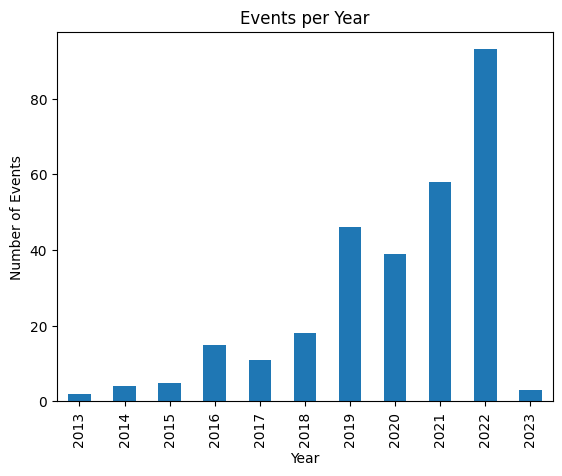

In [58]:
import matplotlib.pyplot as plt

plt.figure()
events_per_year.plot(kind="bar")
plt.title("Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.show()

## Death distribution

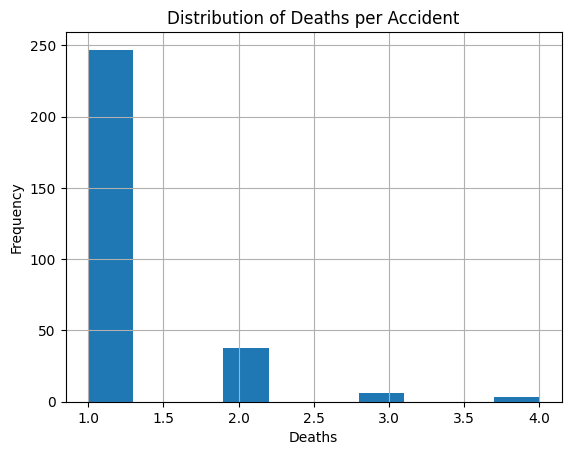

In [56]:
plt.figure()
df["Deaths"].hist()
plt.title("Distribution of Deaths per Accident")
plt.xlabel("Deaths")
plt.ylabel("Frequency")
plt.show()